# Rolling Window Model Summary

This notebook summarizes rolling-window nowcasting predictions versus actual GDP and exports yearly and overall metrics.


## 0. Load Rolling Window Outputs


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.rcParams["axes.unicode_minus"] = False
for font_name in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]:
    current_fonts = plt.rcParams.get("font.sans-serif", [])
    if font_name not in current_fonts:
        plt.rcParams["font.sans-serif"] = [font_name] + current_fonts

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "AGENTS.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "AGENTS.md").exists():
            PROJECT_ROOT = parent
            break

WINDOW_NOTEBOOK_DIR = Path.cwd()
INTERMEDIATE_DIR = PROJECT_ROOT / "outputs" / "pipeline_artifacts"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "processed"
FIT_DIR = next(path for path in INTERMEDIATE_DIR.iterdir() if path.name.startswith("16-"))
NOWCAST_DIR = next(path for path in INTERMEDIATE_DIR.iterdir() if path.name.startswith("17-"))
ESTIMATION_DIR = next(path for path in INTERMEDIATE_DIR.iterdir() if path.name.startswith("8-"))
GDP_READING_DIR = next(path for path in INTERMEDIATE_DIR.iterdir() if path.name.startswith("15-"))

SUMMARY_DIR = WINDOW_NOTEBOOK_DIR / "汇总结果"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_VARIANT_TAG = "rolling_window"

WINDOW_RE = re.compile(r"(\d{4}-\d{4}|\d{6}_\d{6})")
FACTOR_NAMES = ["macro", "real", "nominal"]
FACTOR_AR_ORDER = 6
SUMMARY_END_PERIOD = pd.Period("2025-12", freq="M")

def extract_window_tag(path: Path) -> str:
    match = WINDOW_RE.search(path.stem)
    if not match:
        raise ValueError(f"Cannot extract train window tag from: {path.name}")
    return match.group(1).replace("_", "-") if "_" in match.group(1) else match.group(1)


def metric_frame(df: pd.DataFrame, pred_col: str, actual_col: str, error_col: str) -> pd.Series:
    valid = df.dropna(subset=[pred_col, actual_col, error_col]).copy()
    if valid.empty:
        return pd.Series({
            "n_obs": 0,
            "mean_error_raw": np.nan,
            "mae_raw": np.nan,
            "rmse_raw": np.nan,
            "corr_raw": np.nan,
        })
    return pd.Series({
        "n_obs": int(len(valid)),
        "mean_error_raw": float(valid[error_col].mean()),
        "mae_raw": float(valid[error_col].abs().mean()),
        "rmse_raw": float(np.sqrt((valid[error_col] ** 2).mean())),
        "corr_raw": float(valid[[pred_col, actual_col]].corr().iloc[0, 1]) if len(valid) >= 2 else np.nan,
    })


def add_period_fields(df: pd.DataFrame, window_tag: str, month_col: str = "month") -> pd.DataFrame:
    out = df.copy()
    out["train_window"] = window_tag
    out["month_period"] = pd.PeriodIndex(out[month_col], freq="M")
    out["calendar_year"] = out["month_period"].dt.year.astype(int)
    return out


def summarize_overall(df: pd.DataFrame, pred_col: str, actual_col: str, error_col: str, label: str) -> pd.DataFrame:
    out = metric_frame(df, pred_col, actual_col, error_col).to_frame().T
    out.insert(0, "summary_type", label)
    return out


def summarize_by_year(df: pd.DataFrame, year_col: str, pred_col: str, actual_col: str, error_col: str, label: str) -> pd.DataFrame:
    rows = []
    for year, group in sorted(df.groupby(year_col)):
        row = metric_frame(group, pred_col, actual_col, error_col).to_dict()
        row.update({"summary_type": label, year_col: int(year)})
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_by_window(df: pd.DataFrame, window_col: str, pred_col: str, actual_col: str, error_col: str, label: str) -> pd.DataFrame:
    rows = []
    for window, group in sorted(df.groupby(window_col)):
        row = metric_frame(group, pred_col, actual_col, error_col).to_dict()
        row.update({"summary_type": label, window_col: str(window)})
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_by_horizon(df: pd.DataFrame, pred_col: str, actual_col: str, error_col: str) -> pd.DataFrame:
    rows = []
    for horizon, group in sorted(df.groupby("months_before_quarter_end")):
        row = metric_frame(group, pred_col, actual_col, error_col).to_dict()
        row["months_before_quarter_end"] = int(horizon)
        rows.append(row)
    return pd.DataFrame(rows)


In [2]:
def standardize_prediction_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        "nowcast_gdp_raw": "predicted_gdp_raw",
        "nowcast_error_raw": "prediction_error_raw",
        "abs_error_raw": "prediction_abs_error_raw",
        "squared_error_raw": "prediction_squared_error_raw",
    }
    return df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})


def load_filter_monthly() -> pd.DataFrame:
    frames = []
    for path in sorted(FIT_DIR.glob("*_train_nowcast.csv")):
        window_tag = extract_window_tag(path)
        df = pd.read_csv(path, encoding="utf-8-sig")
        df = standardize_prediction_columns(df)
        df = add_period_fields(df, window_tag)
        df["target_quarter_end_period"] = pd.PeriodIndex(df["target_quarter_end"], freq="M")
        df = df.loc[df["month_period"] <= SUMMARY_END_PERIOD].copy()
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No train nowcast files found under: {FIT_DIR}")
    return pd.concat(frames, ignore_index=True)


def q_start(m: pd.Period) -> bool:
    return m.month in (1, 4, 7, 10)


def quarter_end_month(m: pd.Period) -> pd.Period:
    q_end_month = ((m.month - 1) // 3 + 1) * 3
    return pd.Period(f"{m.year}-{q_end_month:02d}", freq="M")


def state_names() -> list[str]:
    names = []
    for factor in FACTOR_NAMES:
        names += [f"{factor}_alpha_t"] + [f"{factor}_alpha_lag{i}" for i in range(1, FACTOR_AR_ORDER)]
        names += [f"{factor}_S_t", f"{factor}_S_lag1"]
    return names


STATE_NAMES = state_names()
POS = {name: i for i, name in enumerate(STATE_NAMES)}
FACTOR_POS = {factor: i for i, factor in enumerate(FACTOR_NAMES)}


def factor_ar_positions(factor: str) -> list[int]:
    return [POS[f"{factor}_alpha_t"]] + [POS[f"{factor}_alpha_lag{i}"] for i in range(1, FACTOR_AR_ORDER)]


FACTOR_AR_POS = {factor: factor_ar_positions(factor) for factor in FACTOR_NAMES}
FACTOR_S_POS = {factor: POS[f"{factor}_S_t"] for factor in FACTOR_NAMES}
FACTOR_S_LAG1_POS = {factor: POS[f"{factor}_S_lag1"] for factor in FACTOR_NAMES}


def transition_array(month_is_q_start: bool, ar_values: np.ndarray) -> np.ndarray:
    nstate = len(STATE_NAMES)
    T = np.zeros((nstate, nstate), dtype=float)
    st = 0.0 if month_is_q_start else 1.0
    for factor in FACTOR_NAMES:
        ap = FACTOR_AR_POS[factor]
        sp = FACTOR_S_POS[factor]
        spl = FACTOR_S_LAG1_POS[factor]
        rho = ar_values[FACTOR_POS[factor]]
        T[ap[0], ap] = rho
        for lag in range(1, FACTOR_AR_ORDER):
            T[ap[lag], ap[lag - 1]] = 1.0
        T[sp, ap] = rho
        T[sp, sp] = st
        T[spl, sp] = 1.0
    return T


def project_state_to_month_arr(state_vec: np.ndarray, from_month: pd.Period, target_month: pd.Period, ar_arr: np.ndarray) -> np.ndarray:
    out = np.asarray(state_vec, dtype=float).copy()
    cur = from_month
    while cur < target_month:
        nxt = cur + 1
        out = transition_array(q_start(nxt), ar_arr) @ out
        cur = nxt
    return out


def load_smoother_monthly() -> pd.DataFrame:
    frames = []
    for template_path in sorted(FIT_DIR.glob("*_train_nowcast.csv")):
        window_tag = extract_window_tag(template_path)
        template = pd.read_csv(template_path, encoding="utf-8-sig")
        template = add_period_fields(template, window_tag)
        template["target_quarter_end_period"] = pd.PeriodIndex(template["target_quarter_end"], freq="M")
        template = template.loc[template["month_period"] <= SUMMARY_END_PERIOD].copy()

        smooth_path = ESTIMATION_DIR / f"{window_tag}_qn_state.csv"
        ar_path = ESTIMATION_DIR / f"{window_tag}_qn_ar.csv"
        loading_path = ESTIMATION_DIR / f"{window_tag}_qn_loading.csv"
        std_path = PROCESSED_DIR / f"{window_tag}_std_params.csv"

        smooth_df = pd.read_csv(smooth_path, encoding="utf-8-sig").rename(columns={"Unnamed: 0": "month"})
        smooth_df["month_period"] = pd.PeriodIndex(smooth_df["month"], freq="M")
        smooth_df = smooth_df.set_index("month_period").sort_index()

        ar_df = pd.read_csv(ar_path, index_col=0, encoding="utf-8-sig")
        ar_arr = ar_df[[f"rho_{i}" for i in range(1, FACTOR_AR_ORDER + 1)]].to_numpy(dtype=float)

        loading_df = pd.read_csv(loading_path, index_col=0, encoding="utf-8-sig")
        gdp_row = next(idx for idx in loading_df.index if "GDP" in str(idx))
        gdp_loading = loading_df.loc[gdp_row, FACTOR_NAMES].to_numpy(dtype=float)

        std_df = pd.read_csv(std_path, encoding="utf-8-sig").set_index("variable")
        gdp_var = next(idx for idx in std_df.index if "GDP" in str(idx))
        gdp_mean = float(std_df.loc[gdp_var, "mean_train"])
        gdp_std = float(std_df.loc[gdp_var, "std_train"])

        rows = []
        for _, row in template.iterrows():
            m = row["month_period"]
            target_q_end = row["target_quarter_end_period"]
            state_vec = smooth_df.loc[m, STATE_NAMES].to_numpy(dtype=float)
            projected_vec = project_state_to_month_arr(state_vec, m, target_q_end, ar_arr)
            macro_s = float(projected_vec[FACTOR_S_POS["macro"]])
            real_s = float(projected_vec[FACTOR_S_POS["real"]])
            nominal_s = float(projected_vec[FACTOR_S_POS["nominal"]])
            gdp_std_pred = float(np.dot(gdp_loading, np.array([macro_s, real_s, nominal_s], dtype=float)))
            gdp_raw_pred = gdp_std_pred * gdp_std + gdp_mean
            rows.append({
                "month": str(m),
                "train_window": window_tag,
                "month_period": m,
                "calendar_year": int(m.year),
                "target_quarter_end": str(target_q_end),
                "months_before_quarter_end": int(row["months_before_quarter_end"]),
                "actual_gdp_raw": float(row["actual_gdp_raw"]) if pd.notna(row["actual_gdp_raw"]) else np.nan,
                "smoother_gdp_std": gdp_std_pred,
                "smoother_gdp_raw": gdp_raw_pred,
                "error_raw": gdp_raw_pred - float(row["actual_gdp_raw"]) if pd.notna(row["actual_gdp_raw"]) else np.nan,
                "macro_S_target_nowcast": macro_s,
                "real_S_target_nowcast": real_s,
                "nominal_S_target_nowcast": nominal_s,
            })
        frames.append(pd.DataFrame(rows))

    if not frames:
        raise FileNotFoundError(f"No smoother monthly templates found under: {FIT_DIR}")
    return pd.concat(frames, ignore_index=True)


def load_nowcast_monthly() -> pd.DataFrame:
    frames = []
    for path in sorted(NOWCAST_DIR.glob("*_backtest_nowcast.csv")):
        window_tag = extract_window_tag(path)
        df = pd.read_csv(path, encoding="utf-8-sig")
        df = standardize_prediction_columns(df)
        df = add_period_fields(df, window_tag)
        df["target_quarter_end_period"] = pd.PeriodIndex(df["target_quarter_end"], freq="M")
        df["forecast_year"] = df["target_quarter_end_period"].dt.year.astype(int)
        df = df.loc[df["month_period"] <= SUMMARY_END_PERIOD].copy()
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No backtest nowcast files found under: {NOWCAST_DIR}")
    return pd.concat(frames, ignore_index=True)


filter_monthly = load_filter_monthly()
smoother_monthly = load_smoother_monthly()
nowcast_monthly = load_nowcast_monthly()

print(f"Loaded filter monthly rows: {len(filter_monthly)}")
print(f"Loaded smoother monthly rows: {len(smoother_monthly)}")
print(f"Loaded nowcast monthly rows: {len(nowcast_monthly)}")
print(f"Summary output directory: {SUMMARY_DIR}")


Loaded filter monthly rows: 1320
Loaded smoother monthly rows: 1320
Loaded nowcast monthly rows: 120
Summary output directory: e:\财遇见你\大四\申万实习\动态因子模型 git\02_rolling_window_nowcasting\汇总结果


## 1. Export Stitched Nowcasting Table

Combine monthly nowcasting outputs from all rolling windows into one long table for backtesting and external analysis.


In [3]:
nowcast_backtest_stitched = (
    nowcast_monthly.sort_values(
        ["forecast_year", "month_period", "months_before_quarter_end", "train_window", "target_quarter_end_period"]
    )
    .reset_index(drop=True)
    .copy()
)

dup_mask = nowcast_backtest_stitched.duplicated(
    subset=["train_window", "month", "target_quarter_end", "months_before_quarter_end"],
    keep=False,
)
if dup_mask.any():
    raise ValueError(
        "Duplicated nowcast rows detected after stitching. "
        "Check train_window/month/target_quarter_end/months_before_quarter_end uniqueness."
    )

stitched_cols = [
    "train_window",
    "forecast_year",
    "calendar_year",
    "month",
    "information_date",
    "target_quarter_end",
    "months_before_quarter_end",
    "latest_released_monthly_period",
    "latest_released_gdp_quarter_end",
    "predicted_gdp_raw",
    "actual_gdp_raw",
    "prediction_error_raw",
    "prediction_abs_error_raw",
    "prediction_squared_error_raw",
    "model_loading_gdp_raw",
    "macro_S_target_nowcast",
    "real_S_target_nowcast",
    "nominal_S_target_nowcast",
]
stitched_cols = [col for col in stitched_cols if col in nowcast_backtest_stitched.columns]
nowcast_backtest_stitched = nowcast_backtest_stitched[stitched_cols].copy()

stitched_path = SUMMARY_DIR / "nowcast_monthly_stitched_backtest.csv"
nowcast_backtest_stitched.to_csv(stitched_path, encoding="utf-8-sig", index=False)

print(f"Stitched nowcasting rows: {len(nowcast_backtest_stitched)}")
print(f"Saved stitched backtest to: {stitched_path}")
display(nowcast_backtest_stitched.head(20))


Stitched nowcasting rows: 120
Saved stitched backtest to: e:\财遇见你\大四\申万实习\动态因子模型 git\02_rolling_window_nowcasting\汇总结果\nowcast_monthly_stitched_backtest.csv


,train_window,forecast_year,calendar_year,month,information_date,target_quarter_end,months_before_quarter_end,latest_released_monthly_period,latest_released_gdp_quarter_end,predicted_gdp_raw,actual_gdp_raw,prediction_error_raw,prediction_abs_error_raw,prediction_squared_error_raw,model_loading_gdp_raw,macro_S_target_nowcast,real_S_target_nowcast,nominal_S_target_nowcast
0,2005-2014,2015,2015,2015-01,2015-01-19,2015-03,2,2015-01,2015-01,7.358259,7.1,0.258259,0.258259,6.669793e-02,7.358259,-137.786435,4.865300,203.906865
1,2005-2014,2015,2015,2015-02,2015-02-19,2015-03,1,2015-02,2015-01,7.008877,7.1,-0.091123,0.091123,8.303406e-03,7.008877,-153.367663,8.196988,201.773403
2,2005-2014,2015,2015,2015-03,2015-03-19,2015-03,0,2015-03,2015-01,6.705923,7.1,-0.394077,0.394077,1.552970e-01,6.705923,-162.637924,16.208863,240.895119
3,2005-2014,2015,2015,2015-04,2015-04-19,2015-06,2,2015-04,2015-04,6.694684,7.1,-0.405316,0.405316,1.642808e-01,6.694684,-159.941410,20.179218,233.336339
4,2005-2014,2015,2015,2015-05,2015-05-19,2015-06,1,2015-05,2015-04,6.828817,7.1,-0.271183,0.271183,7.353997e-02,6.828817,-156.587002,15.725869,232.266598
5,2005-2014,2015,2015,2015-06,2015-06-19,2015-06,0,2015-06,2015-04,6.925130,7.1,-0.174870,0.174870,3.057962e-02,6.925130,-155.040383,11.486863,221.618910
6,2005-2014,2015,2015,2015-07,2015-07-19,2015-09,2,2015-07,2015-07,7.458847,7.0,0.458847,0.458847,2.105406e-01,7.458847,-139.256743,-3.289611,210.325559
7,2005-2014,2015,2015,2015-08,2015-08-19,2015-09,1,2015-08,2015-07,7.308410,7.0,0.308410,0.308410,9.511660e-02,7.308410,-139.051495,6.498106,213.059415
8,2005-2014,2015,2015,2015-09,2015-09-19,2015-09,0,2015-09,2015-07,7.216429,7.0,0.216429,0.216429,4.684169e-02,7.216429,-141.773145,9.042844,221.090241
9,2005-2014,2015,2015,2015-10,2015-10-19,2015-12,2,2015-10,2015-10,7.017586,6.9,0.117586,0.117586,1.382642e-02,7.017586,-139.876199,23.943940,207.781982


## 2. Filter Monthly Metrics


In [4]:
def plot_monthly_predictions(df: pd.DataFrame, pred_col: str, actual_col: str, title: str, png_path: Path, point_size: float = 6.0) -> None:
    plot_df = df.sort_values("month_period").copy()
    x = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(x, plot_df[pred_col], marker="o", markersize=np.sqrt(point_size), linewidth=0.8, label="预测 GDP")
    ax.plot(x, plot_df[actual_col], marker="o", markersize=np.sqrt(point_size), linewidth=0.8, color="black", alpha=0.9, label="实际 GDP")
    tick_idx = np.linspace(0, len(plot_df) - 1, min(24, len(plot_df)), dtype=int) if len(plot_df) else []
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([str(plot_df.iloc[i]["month_period"]) for i in tick_idx], rotation=60, ha="right")
    ax.set_title(title)
    ax.set_xlabel("月份")
    ax.set_ylabel("GDP同比")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    plt.show()


def plot_year_panels(df: pd.DataFrame, pred_col: str, actual_col: str, year_col: str, title: str, png_path: Path, point_size: float = 5.0) -> None:
    years = sorted(df[year_col].dropna().unique().tolist())
    n = len(years)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.4 * nrows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, year in zip(axes.flat, years):
        ax.axis("on")
        sub = df.loc[df[year_col] == year].sort_values("month_period").copy()
        x = np.arange(len(sub))
        ax.plot(x, sub[pred_col], marker="o", markersize=np.sqrt(point_size), linewidth=0.8, label="预测 GDP")
        ax.plot(x, sub[actual_col], marker="o", markersize=np.sqrt(point_size), linewidth=0.8, color="black", alpha=0.9, label="实际 GDP")
        ax.set_title(str(year))
        ax.set_xticks(x)
        ax.set_xticklabels([str(m) for m in sub["month_period"]], rotation=60, ha="right", fontsize=8)
        ax.grid(True, axis="y", alpha=0.25)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle(title, y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    plt.show()


,summary_type,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw
0,filter_monthly_overall,1320.0,-0.006734,0.404259,0.554037,0.964836


,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw,summary_type,train_window
0,120.0,0.061717,0.577048,0.748563,0.946193,filter_monthly_by_window,2005-2014
1,120.0,0.021795,0.581934,0.728984,0.953457,filter_monthly_by_window,2006-2015
2,120.0,0.025173,0.327695,0.420638,0.966084,filter_monthly_by_window,2008-2017
3,120.0,0.041291,0.365048,0.516104,0.939386,filter_monthly_by_window,2009-2018
4,120.0,0.085762,0.217616,0.272872,0.982363,filter_monthly_by_window,2010-2019
5,120.0,0.005898,0.293754,0.420472,0.942023,filter_monthly_by_window,2011-2020
6,120.0,-0.008525,0.283900,0.419879,0.916106,filter_monthly_by_window,2012-2021
7,120.0,-0.090291,0.399139,0.540588,0.916765,filter_monthly_by_window,2013-2022
8,120.0,-0.115466,0.479818,0.617748,0.878387,filter_monthly_by_window,2014-2023
9,120.0,-0.073180,0.444358,0.590247,0.874612,filter_monthly_by_window,2015-2024


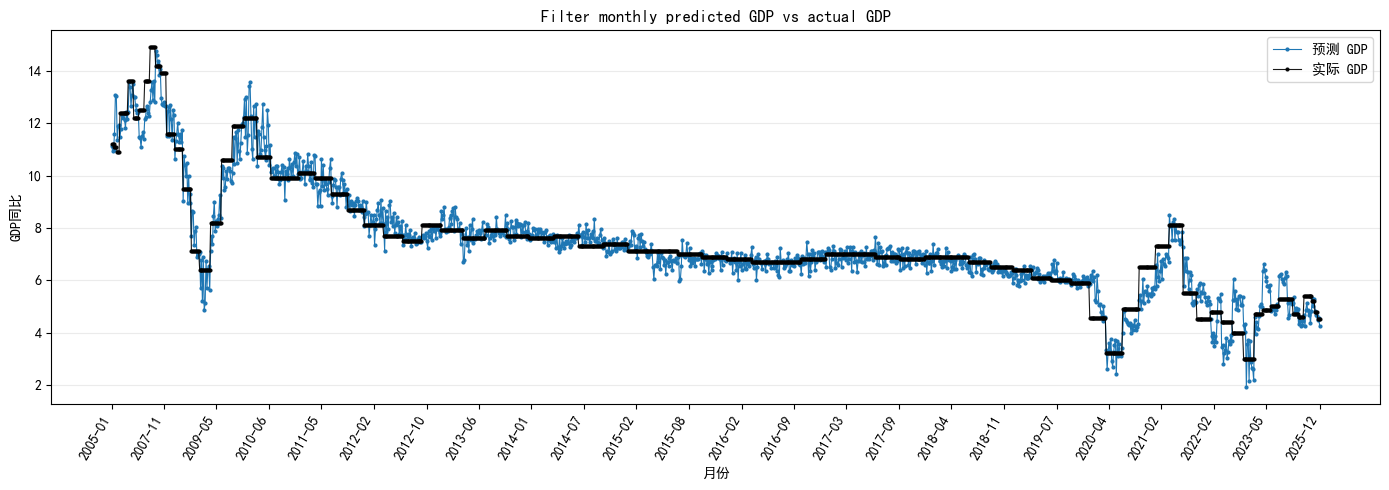

In [5]:
filter_overall = summarize_overall(
    filter_monthly,
    pred_col="predicted_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="prediction_error_raw",
    label="filter_monthly_overall",
)
filter_by_window = summarize_by_window(
    filter_monthly,
    window_col="train_window",
    pred_col="predicted_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="prediction_error_raw",
    label="filter_monthly_by_window",
)

display(filter_overall)
display(filter_by_window)

filter_overall.to_csv(SUMMARY_DIR / "filter_monthly_overall_metrics.csv", encoding="utf-8-sig", index=False)
filter_by_window.to_csv(SUMMARY_DIR / "filter_monthly_by_window_metrics.csv", encoding="utf-8-sig", index=False)

plot_monthly_predictions(
    filter_monthly,
    pred_col="predicted_gdp_raw",
    actual_col="actual_gdp_raw",
    title="Filter monthly predicted GDP vs actual GDP",
    png_path=SUMMARY_DIR / "filter_monthly_gdp_overall.png",
    point_size=4.0,
)


## 3. Smoother Monthly Metrics


,summary_type,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw
0,smoother_monthly_overall,1320.0,-0.026779,0.213619,0.301108,0.989707


,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw,summary_type,train_window
0,120.0,-0.007968,0.247705,0.354859,0.988155,smoother_monthly_by_window,2005-2014
1,120.0,-0.009112,0.174736,0.230777,0.995428,smoother_monthly_by_window,2006-2015
2,120.0,-0.007004,0.225861,0.279630,0.984992,smoother_monthly_by_window,2008-2017
3,120.0,-0.016321,0.291106,0.402717,0.963244,smoother_monthly_by_window,2009-2018
4,120.0,0.012811,0.121176,0.145136,0.994472,smoother_monthly_by_window,2010-2019
5,120.0,-0.006477,0.229911,0.342331,0.961611,smoother_monthly_by_window,2011-2020
6,120.0,-0.046260,0.185756,0.244657,0.973907,smoother_monthly_by_window,2012-2021
7,120.0,-0.067551,0.183501,0.269420,0.979753,smoother_monthly_by_window,2013-2022
8,120.0,-0.068971,0.239476,0.325808,0.967024,smoother_monthly_by_window,2014-2023
9,120.0,-0.055756,0.252064,0.348694,0.958137,smoother_monthly_by_window,2015-2024


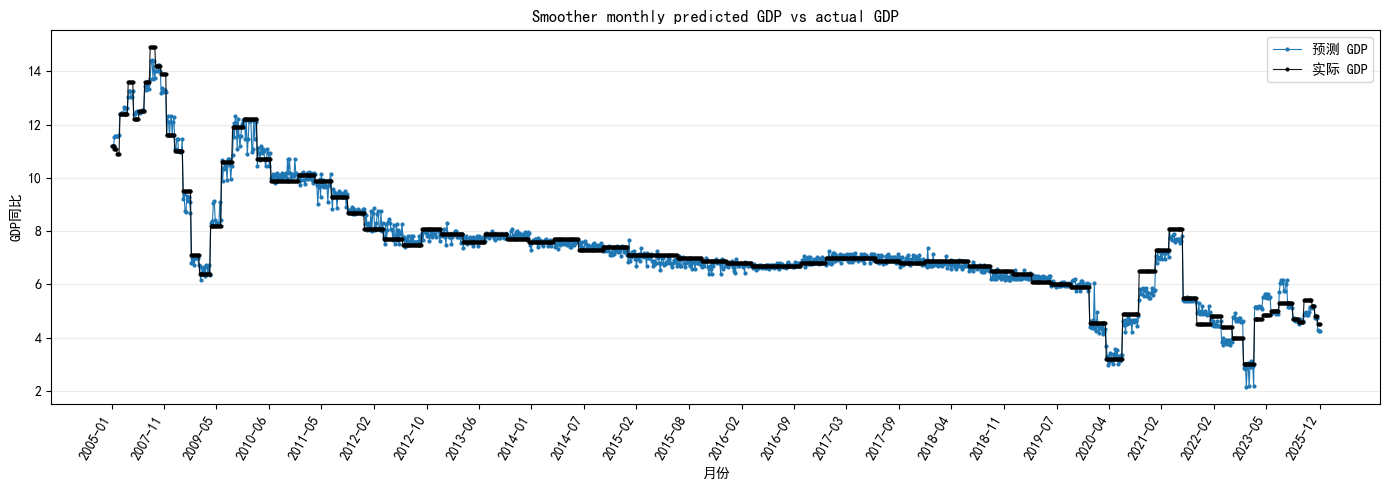

In [6]:
smoother_overall = summarize_overall(
    smoother_monthly,
    pred_col="smoother_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="error_raw",
    label="smoother_monthly_overall",
)
smoother_by_window = summarize_by_window(
    smoother_monthly,
    window_col="train_window",
    pred_col="smoother_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="error_raw",
    label="smoother_monthly_by_window",
)

display(smoother_overall)
display(smoother_by_window)

smoother_overall.to_csv(SUMMARY_DIR / "smoother_monthly_overall_metrics.csv", encoding="utf-8-sig", index=False)
smoother_by_window.to_csv(SUMMARY_DIR / "smoother_monthly_by_window_metrics.csv", encoding="utf-8-sig", index=False)

plot_monthly_predictions(
    smoother_monthly,
    pred_col="smoother_gdp_raw",
    actual_col="actual_gdp_raw",
    title="Smoother monthly predicted GDP vs actual GDP",
    png_path=SUMMARY_DIR / "smoother_monthly_gdp_overall.png",
    point_size=4.0,
)


## 4. Nowcasting Monthly Metrics


,summary_type,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw
0,nowcast_monthly_overall,120.0,0.122454,1.318619,2.937501,0.456337


,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw,summary_type,forecast_year
0,12.0,0.011991,0.234752,0.269661,-0.222376,nowcast_monthly_by_year,2015
1,12.0,-0.116632,0.168583,0.237064,0.778703,nowcast_monthly_by_year,2016
2,12.0,0.340238,0.340238,0.389050,0.312418,nowcast_monthly_by_year,2018
3,12.0,-0.099276,0.190411,0.236198,0.242142,nowcast_monthly_by_year,2019
4,12.0,1.780687,5.235619,6.959705,0.095382,nowcast_monthly_by_year,2020
5,12.0,-1.817421,3.681031,5.679663,0.344448,nowcast_monthly_by_year,2021
6,12.0,1.164157,1.259308,1.475545,0.797588,nowcast_monthly_by_year,2022
7,12.0,0.327137,1.483533,1.675054,0.835693,nowcast_monthly_by_year,2023
8,12.0,-0.246973,0.364360,0.431544,0.401727,nowcast_monthly_by_year,2024
9,12.0,-0.119367,0.228350,0.296205,0.673048,nowcast_monthly_by_year,2025


,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw,months_before_quarter_end
0,40.0,0.157425,0.896548,1.934212,0.819895,0
1,40.0,0.060513,1.371387,3.089853,0.361155,1
2,40.0,0.149424,1.687920,3.549419,0.269617,2


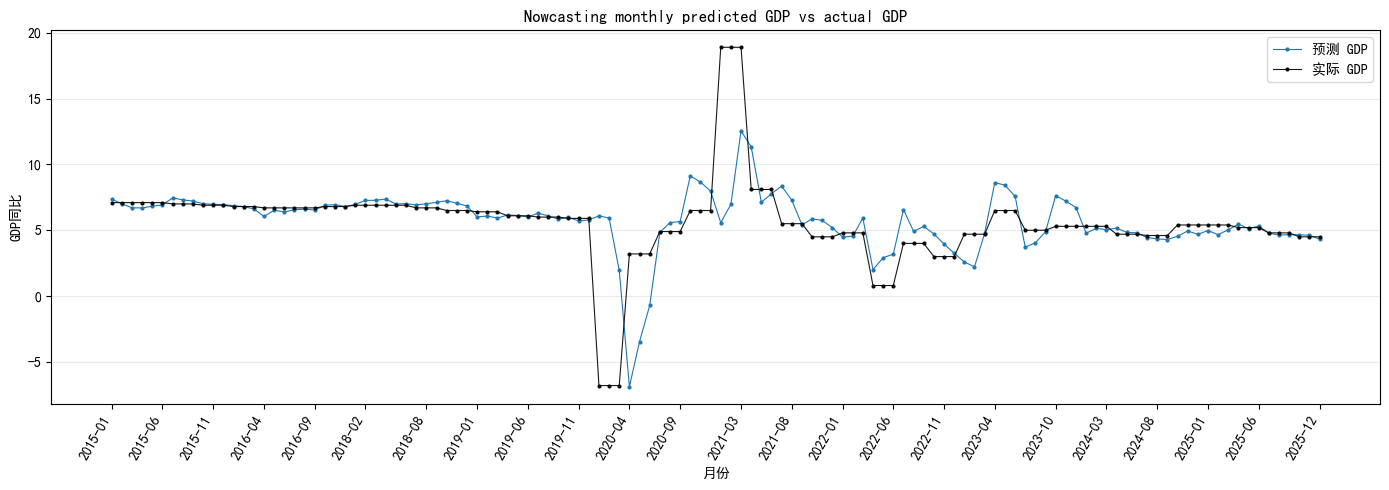

In [7]:
nowcast_overall = summarize_overall(
    nowcast_monthly,
    pred_col="predicted_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="prediction_error_raw",
    label="nowcast_monthly_overall",
)
nowcast_by_year = summarize_by_year(
    nowcast_monthly,
    year_col="forecast_year",
    pred_col="predicted_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="prediction_error_raw",
    label="nowcast_monthly_by_year",
)
nowcast_by_horizon = summarize_by_horizon(
    nowcast_monthly.loc[nowcast_monthly["months_before_quarter_end"].isin([0, 1, 2])].copy(),
    pred_col="predicted_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="prediction_error_raw",
)

display(nowcast_overall)
display(nowcast_by_year)
display(nowcast_by_horizon)

nowcast_overall.to_csv(SUMMARY_DIR / "nowcast_monthly_overall_metrics.csv", encoding="utf-8-sig", index=False)
nowcast_by_year.to_csv(SUMMARY_DIR / "nowcast_monthly_by_year_metrics.csv", encoding="utf-8-sig", index=False)
nowcast_by_horizon.to_csv(SUMMARY_DIR / "nowcast_monthly_by_horizon_0_2_metrics.csv", encoding="utf-8-sig", index=False)

plot_monthly_predictions(
    nowcast_monthly,
    pred_col="predicted_gdp_raw",
    actual_col="actual_gdp_raw",
    title="Nowcasting monthly predicted GDP vs actual GDP",
    png_path=SUMMARY_DIR / "nowcast_monthly_gdp_overall.png",
    point_size=4.0,
)


## 5. Export Prediction File


In [8]:
import pandas as pd

# 1. 读取原始 CSV 文件
file_path = SUMMARY_DIR / "nowcast_monthly_stitched_backtest.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# 2. 只保留 month 和 predicted_gdp_raw 两列，并重新命名
df_new = df[["month", "predicted_gdp_raw"]].copy()
df_new.columns = ["month", "nowcasting_GDP"]  # 重命名列名

# 3. 保存到指定路径
save_path = PROJECT_ROOT / "outputs" / "final_results" / "Rolling Window Nowcasting GDP result.csv"
df_new.to_csv(save_path, index=False, encoding="utf-8-sig")

print("文件已成功保存！")
print(f"保存路径：{save_path}")

文件已成功保存！
保存路径：E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\final_results\Rolling Window Nowcasting GDP result.csv
